# Behavioral Modeling and Recommendation Systems

### Importing libraries and dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
aisles = pd.read_csv("C:/Users/Samin  Mahboubfar/Desktop/tamrin/aisles.csv")
aisles

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation
...,...,...
129,130,hot cereal pancake mixes
130,131,dry pasta
131,132,beauty
132,133,muscles joints pain relief


In [3]:
products = pd.read_csv("C:/Users/Samin  Mahboubfar/Desktop/tamrin/products.csv")
products

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
...,...,...,...,...
49683,49684,"Vodka, Triple Distilled, Twist of Vanilla",124,5
49684,49685,En Croute Roast Hazelnut Cranberry,42,1
49685,49686,Artisan Baguette,112,3
49686,49687,Smartblend Healthy Metabolism Dry Cat Food,41,8


In [4]:
orders = pd.read_csv("C:/Users/Samin  Mahboubfar/Desktop/tamrin/orders.csv")
orders

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0
...,...,...,...,...,...,...,...
3421078,2266710,206209,prior,10,5,18,29.0
3421079,1854736,206209,prior,11,4,10,30.0
3421080,626363,206209,prior,12,1,12,18.0
3421081,2977660,206209,prior,13,1,12,7.0


In [5]:
#orders["eval_set"].values()
orders['eval_set'].unique()

array(['prior', 'train', 'test'], dtype=object)

In [6]:
(orders['eval_set'] == 'prior').sum()

3214874

In [7]:
(orders['eval_set'] == 'train').sum()

131209

In [8]:
(orders['eval_set'] == 'test').sum()

75000

In [9]:
order_products__prior = pd.read_csv("C:/Users/Samin  Mahboubfar/Desktop/tamrin/order_products__prior.csv")
order_products__prior

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0
...,...,...,...,...
32434484,3421083,39678,6,1
32434485,3421083,11352,7,0
32434486,3421083,4600,8,0
32434487,3421083,24852,9,1


In [10]:
order_products__train = pd.read_csv("C:/Users/Samin  Mahboubfar/Desktop/tamrin/order_products__train.csv")
order_products__train

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1
...,...,...,...,...
1384612,3421063,14233,3,1
1384613,3421063,35548,4,1
1384614,3421070,35951,1,1
1384615,3421070,16953,2,1


In [11]:
departments = pd.read_csv("C:/Users/Samin  Mahboubfar/Desktop/tamrin/departments.csv")
departments

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol
5,6,international
6,7,beverages
7,8,pets
8,9,dry goods pasta
9,10,bulk


## EDA

In [12]:
items = [
    ("aisles", aisles),
    ("products", products),
    ("orders", orders),
    ("departments", departments),
    ("order_products__train", order_products__train),
    ("order_products__prior", order_products__prior)
]

In [13]:
#Checking the size of each dataframe
for name, df in items:
    print(name, ":", df.shape)

aisles : (134, 2)
products : (49688, 4)
orders : (3421083, 7)
departments : (21, 2)
order_products__train : (1384617, 4)
order_products__prior : (32434489, 4)


In [14]:
#
for name, df in items:
    print(name,":", df.info(),"**************************************")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
aisles : None **************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49688 non-null  int64 
 1   product_name   49688 non-null  object
 2   aisle_id       49688 non-null  int64 
 3   department_id  49688 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
products : None **************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------          

In [15]:
#Checking for duplicated items in dataframes
for name, df in items:
    print(name, ":", df.duplicated().sum())

aisles : 0
products : 0
orders : 0
departments : 0
order_products__train : 0
order_products__prior : 0


In [9]:
#Checking for null values in dataframes
summary_list = []

for name, df in items:
    null_counts = df.isnull().sum()

    # Convert the null counts Series to a DataFrame for better presentation
    null_counts_df = pd.DataFrame({
        'column_name': null_counts.index,
        'null_count': null_counts.values
    })

    # Add a column for the DataFrame name
    null_counts_df['dataframe_name'] = name

    # Append this summary DataFrame to our list
    summary_list.append(null_counts_df)

# Concatenate all the summary DataFrames into a single DataFrame
final_summary_df = pd.concat(summary_list, ignore_index=True)
print(final_summary_df)

               column_name  null_count         dataframe_name
0                 aisle_id           0                 aisles
1                    aisle           0                 aisles
2               product_id           0               products
3             product_name           0               products
4                 aisle_id           0               products
5            department_id           0               products
6                 order_id           0                 orders
7                  user_id           0                 orders
8                 eval_set           0                 orders
9             order_number           0                 orders
10               order_dow           0                 orders
11       order_hour_of_day           0                 orders
12  days_since_prior_order      206209                 orders
13           department_id           0            departments
14              department           0            departments
15      

In [10]:
#This means that 206,209 orders have an order_number of 1.
print(orders[orders['days_since_prior_order'].isnull()]['order_number'].value_counts())

order_number
1    206209
Name: count, dtype: int64


In [13]:
#Filling these nulls with 0
orders['days_since_prior_order'] = orders['days_since_prior_order'].fillna(0)
orders.isnull().sum()

order_id                  0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
dtype: int64

#### Descriptive statistics:

In [19]:
orders.describe()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06
mean,1.710542e+06,1.029782e+05,1.715486e+01,2.776219e+00,1.345202e+01,1.044488e+01
std,9.875817e+05,5.953372e+04,1.773316e+01,2.046829e+00,4.226088e+00,9.308727e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.552715e+05,5.139400e+04,5.000000e+00,1.000000e+00,1.000000e+01,4.000000e+00
50%,1.710542e+06,1.026890e+05,1.100000e+01,3.000000e+00,1.300000e+01,7.000000e+00
75%,2.565812e+06,1.543850e+05,2.300000e+01,5.000000e+00,1.600000e+01,1.500000e+01
max,3.421083e+06,2.062090e+05,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01


In [20]:
order_products__train.describe()

,order_id,product_id,add_to_cart_order,reordered
count,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06
mean,1.706298e+06,2.555624e+04,8.758044e+00,5.985944e-01
std,9.897326e+05,1.412127e+04,7.423936e+00,4.901829e-01
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,8.433700e+05,1.338000e+04,3.000000e+00,0.000000e+00
50%,1.701880e+06,2.529800e+04,7.000000e+00,1.000000e+00
75%,2.568023e+06,3.794000e+04,1.200000e+01,1.000000e+00
max,3.421070e+06,4.968800e+04,8.000000e+01,1.000000e+00


In [21]:
order_products__prior.describe()

,order_id,product_id,add_to_cart_order,reordered
count,3.243449e+07,3.243449e+07,3.243449e+07,3.243449e+07
mean,1.710749e+06,2.557634e+04,8.351076e+00,5.896975e-01
std,9.873007e+05,1.409669e+04,7.126671e+00,4.918886e-01
min,2.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,8.559430e+05,1.353000e+04,3.000000e+00,0.000000e+00
50%,1.711048e+06,2.525600e+04,6.000000e+00,1.000000e+00
75%,2.565514e+06,3.793500e+04,1.100000e+01,1.000000e+00
max,3.421083e+06,4.968800e+04,1.450000e+02,1.000000e+00


### Plots:

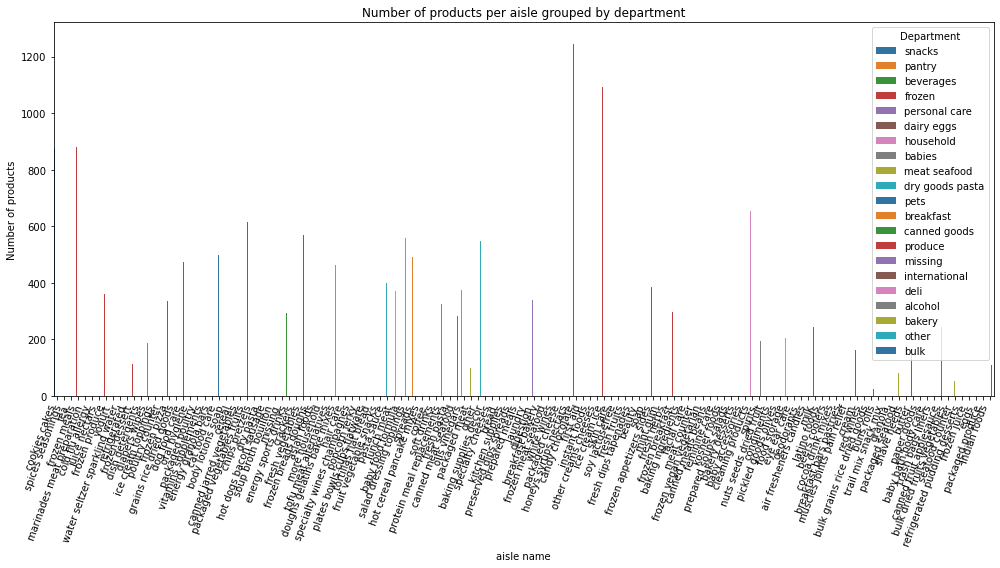

In [22]:
#Number of products per aisle, grouped by department 
products_df = pd.merge(products, aisles, on='aisle_id', how='left')
products_df = pd.merge(products_df, departments, on='department_id', how='left')

plt.figure(figsize=(14, 8))
#Using hue to group by department
sns.countplot(data=products_df, x='aisle', hue='department', palette='tab10')
plt.title('Number of products per aisle grouped by department')
plt.xlabel('aisle name')
plt.ylabel('Number of products')
plt.xticks(rotation=70, ha='right')
plt.legend(title="Department")
plt.tight_layout()
plt.show()

In [23]:
dept_aisle_counts = (
    products_df
    .groupby(['department', 'aisle'])
    .size()
    .reset_index(name='product_count')
    .sort_values(by='product_count', ascending=False)
)

dept_aisle_counts.head()

,department,aisle,product_count
85,missing,missing,1258
123,snacks,candy chocolate,1246
63,frozen,ice cream ice,1091
115,personal care,vitamins supplements,1038
42,dairy eggs,yogurt,1026


In [24]:
(aisles['aisle'] == 'missing').sum()

1

In [25]:
(departments['department'] == 'missing').sum()

1

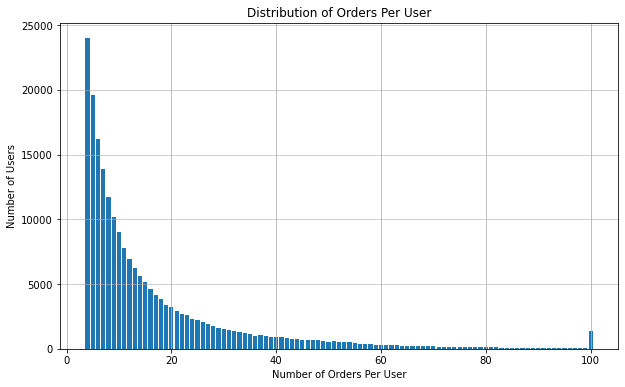

In [26]:
#Distribution of orders per user
orders_per_user = orders.groupby('user_id')['order_id'].count()

# Plotting the distribution
plt.figure(figsize=(10, 6))
orders_per_user.hist(bins=range(min(orders_per_user), max(orders_per_user) + 2), align='left', rwidth=0.8)
plt.title('Distribution of Orders Per User')
plt.xlabel('Number of Orders Per User')
plt.ylabel('Number of Users')
#plt.xticks(range(min(orders_per_user), max(orders_per_user) + 1))
plt.grid(axis='y', alpha=0.75)
plt.show()

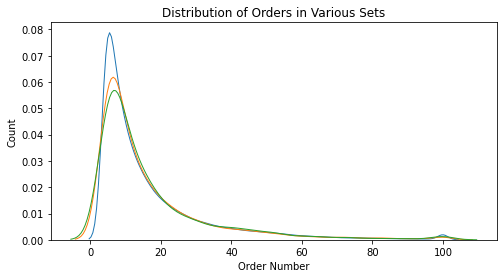

In [27]:
fig, ax = plt.subplots(figsize = (8,4))
ax = sns.kdeplot(orders_per_user[orders.eval_set == 'prior'], label = "Prior set", lw = 1)
ax = sns.kdeplot(orders_per_user[orders.eval_set == 'train'], label = "Train set", lw = 1)
ax = sns.kdeplot(orders_per_user[orders.eval_set == 'test'], label = "Test set", lw = 1)
ax.set_xlabel('Order Number')
ax.set_ylabel('Count')
ax.tick_params(axis = 'both', labelsize = 10)
ax.set_title('Distribution of Orders in Various Sets')
fig.savefig('Distribution of Orders in Various Sets.png')
plt.show()

C:\Users\Dell\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


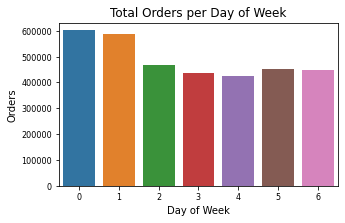

In [28]:
fig, ax = plt.subplots(figsize = (5,3))
ax = sns.countplot(orders.order_dow)
ax.set_xlabel('Day of Week', size = 10)
ax.set_ylabel('Orders', size = 10)
ax.tick_params(axis = 'both', labelsize = 8)
ax.set_title('Total Orders per Day of Week')
fig.savefig('Total Orders per Day of Week.png')
plt.show()

C:\Users\Dell\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


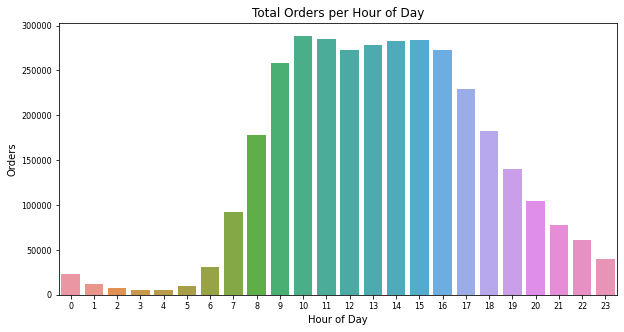

In [29]:
fig, ax = plt.subplots(figsize = (10,5))
ax = sns.countplot(orders.order_hour_of_day)
ax.set_xlabel('Hour of Day', size = 10 )
ax.set_ylabel('Orders', size = 10)
ax.tick_params(axis = 'both', labelsize = 8)
ax.set_title('Total Orders per Hour of Day')
fig.savefig('Total Orders per Hour of Day.png')
plt.show()

In [30]:
orders_per_user.max()

100

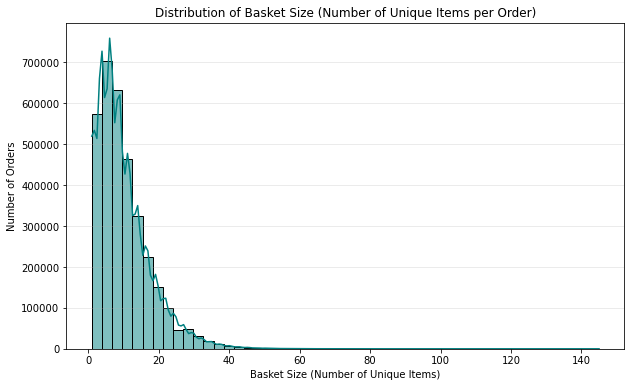

In [31]:
#Distribution of basket size

#Combining the order_products tables
order_products_all = pd.concat([
    order_products__train[['order_id', 'product_id']],
    order_products__prior[['order_id', 'product_id']]
], ignore_index=True)

#Calculating basket size (number of unique products per order)
basket_size_per_order = order_products_all.groupby('order_id')['product_id'].nunique().reset_index()
basket_size_per_order.rename(columns={'product_id': 'basket_size'}, inplace=True)

#Ploting the histogram for basket size distribution
plt.figure(figsize=(10, 6))

sns.histplot(basket_size_per_order['basket_size'], bins=50, kde=True, color='teal')
plt.title("Distribution of Basket Size (Number of Unique Items per Order)")
plt.xlabel("Basket Size (Number of Unique Items)")
plt.ylabel("Number of Orders")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [32]:
#Global Reorder Rate Analysis
#Combine both order_products tables (train + prior)
order_products_all = pd.concat([
    order_products__train[['order_id', 'product_id', 'reordered']],
    order_products__prior[['order_id', 'product_id', 'reordered']]
], ignore_index=True)

#Calculate global reorder rate
global_reorder_rate = order_products_all['reordered'].mean()

reorder_counts = order_products_all['reordered'].value_counts(normalize=False)
reorder_percentage = order_products_all['reordered'].value_counts(normalize=True) * 100

print("Global Reorder Rate:", round(global_reorder_rate * 100, 2), "%")
print("\nCount of reordered vs not reordered:\n", reorder_counts)
print("\nPercentage distribution:\n", reorder_percentage)


Global Reorder Rate: 59.01 %

Count of reordered vs not reordered:
 1    19955360
0    13863746
Name: reordered, dtype: int64

Percentage distribution:
 1    59.006172
0    40.993828
Name: reordered, dtype: float64


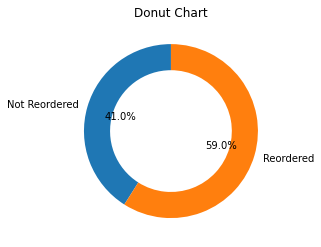

In [33]:
sizes = [reorder_percentage.get(0, 0), reorder_percentage.get(1, 0)] # Percentage for 0, then for 1
labels = ['Not Reordered', 'Reordered']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, wedgeprops={'width':0.3})
plt.title("Donut Chart")
plt.show()

In [34]:
#Product popularity and long-tail behavior

#Number of times each product is ordered
popular_product_df = order_products_all.groupby('product_id')['order_id'].count().reset_index()
popular_product_df.columns = ['product_id', 'order_count']

popular_product_df = pd.merge(products, popular_product_df, on='product_id', how='left')
    
top_products = popular_product_df.sort_values(by='order_count', ascending=False).head(10)
top_products

,product_id,product_name,aisle_id,department_id,order_count
24851,24852,Banana,24,4,491291.0
13175,13176,Bag of Organic Bananas,24,4,394930.0
21136,21137,Organic Strawberries,24,4,275577.0
21902,21903,Organic Baby Spinach,123,4,251705.0
47208,47209,Organic Hass Avocado,24,4,220877.0
47765,47766,Organic Avocado,24,4,184224.0
47625,47626,Large Lemon,24,4,160792.0
16796,16797,Strawberries,24,4,149445.0
26208,26209,Limes,24,4,146660.0
27844,27845,Organic Whole Milk,84,16,142813.0


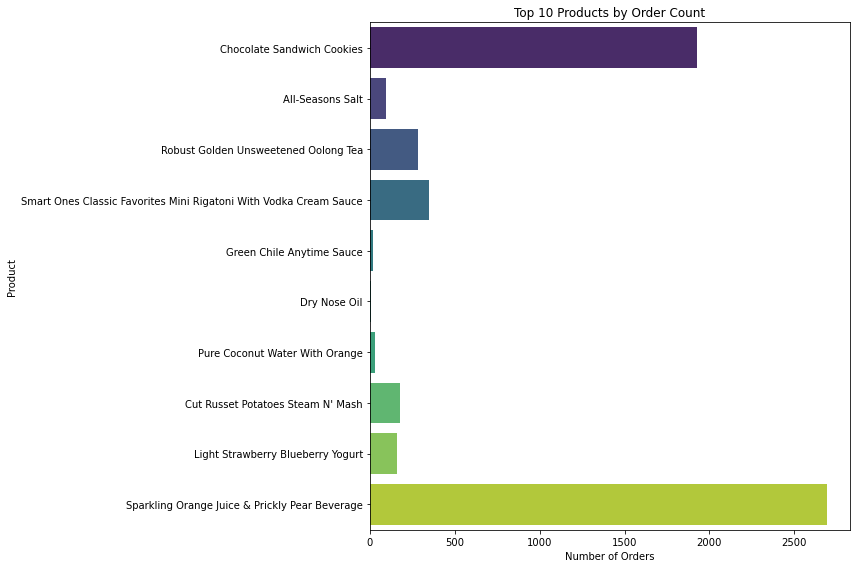

In [35]:
top_10 = popular_product_df.head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_10['order_count'], y=top_10['product_name'], palette='viridis')
plt.title('Top 10 Products by Order Count')
plt.xlabel('Number of Orders')
plt.ylabel('Product')
plt.tight_layout() 
plt.show()

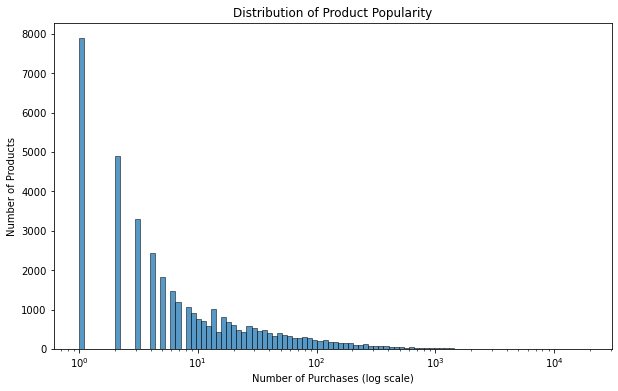

In [36]:
#Distribution of Product Popularity
counts = order_products__train['product_id'].value_counts()

plt.figure(figsize=(10,6))
sns.histplot(counts, bins=100, log_scale=(True, False))
plt.title("Distribution of Product Popularity")
plt.xlabel("Number of Purchases (log scale)")
plt.ylabel("Number of Products")
plt.show()

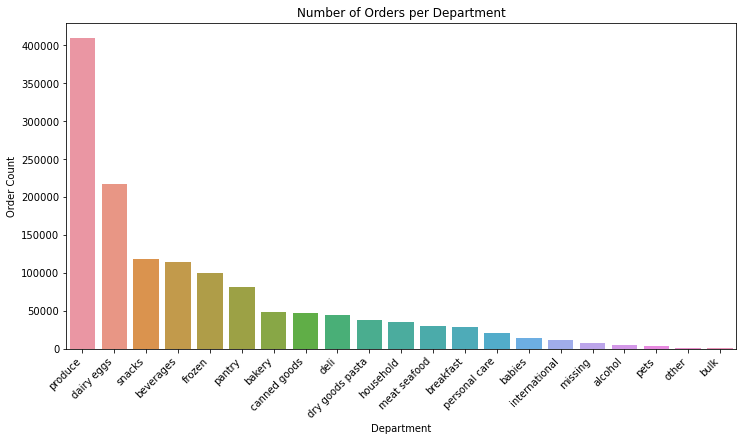

In [37]:
#Departments
dept_orders = (
    order_products__train.merge(products, on="product_id")
    .merge(departments, on="department_id")
    ['department']
    .value_counts()
)

plt.figure(figsize=(12,6))
sns.barplot(x=dept_orders.index, y=dept_orders.values)
plt.xticks(rotation=45, ha='right')
plt.title("Number of Orders per Department")
plt.xlabel("Department")
plt.ylabel("Order Count")
plt.show()

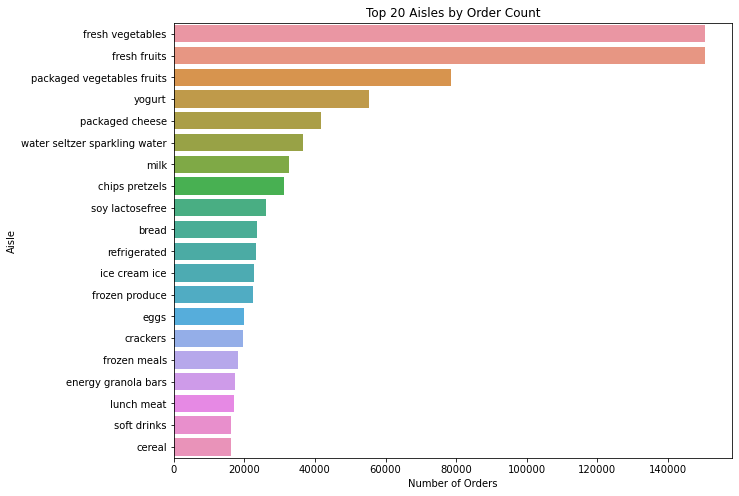

In [38]:
#Aisles
aisle_orders = (
    order_products__train.merge(products, on="product_id")
    .merge(aisles, on="aisle_id")
    ['aisle']
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10,8))
sns.barplot(y=aisle_orders.index, x=aisle_orders.values)
plt.title("Top 20 Aisles by Order Count")
plt.xlabel("Number of Orders")
plt.ylabel("Aisle")
plt.show()

D:\anacondaistall\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
D:\anacondaistall\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


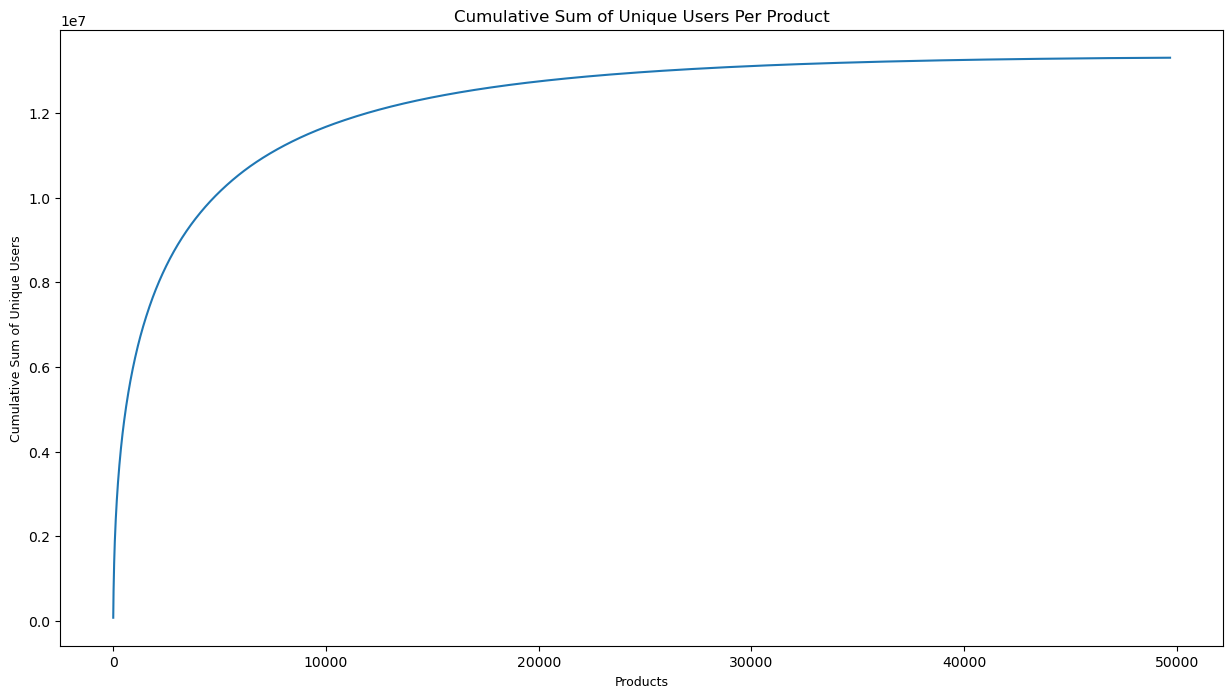

In [54]:
#Cumulative Sum of Unique Users Per Product for prior data
#Note: This code should be run after feature engineering part

product_unique_users = prior_df.groupby('product_name')['user_id'].nunique().reset_index().rename(columns={'user_id':'total_users'})

temp_df = product_unique_users.sort_values("total_users", ascending=False)
temp_df['cum_users'] = temp_df['total_users'].cumsum()
temp_df = temp_df.reset_index(drop=True)

fig, ax = plt.subplots(figsize=(15,8))
ax = sns.lineplot(x = temp_df.index, y=temp_df.cum_users)
ax.set_xlabel("Products", size = 9)
ax.set_ylabel("Cumulative Sum of Unique Users", size = 9)
ax.set_title("Cumulative Sum of Unique Users Per Product", size = 12)
plt.show()

Outlier Detection

<AxesSubplot:xlabel='order_number'>

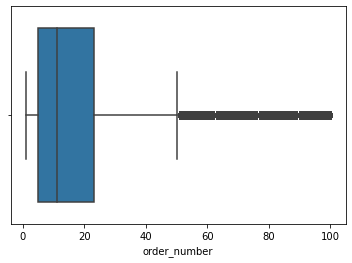

In [39]:
sns.boxplot(x=orders["order_number"])

<AxesSubplot:xlabel='order_hour_of_day'>

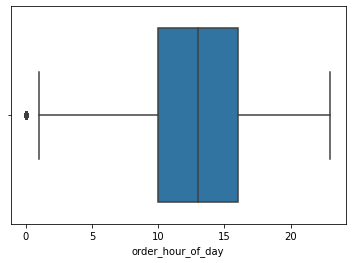

In [40]:
sns.boxplot(x=orders["order_hour_of_day"])

<AxesSubplot:xlabel='days_since_prior_order'>

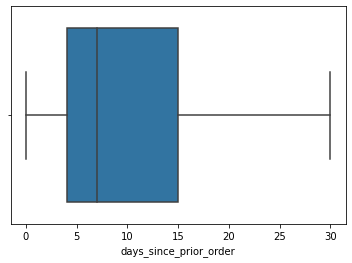

In [41]:
sns.boxplot(x=orders["days_since_prior_order"])

<AxesSubplot:xlabel='add_to_cart_order'>

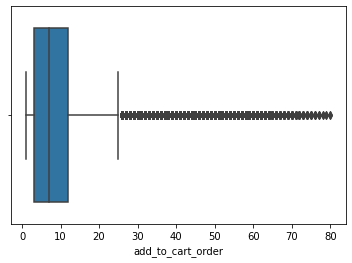

In [42]:
sns.boxplot(x=order_products__train["add_to_cart_order"])

<AxesSubplot:xlabel='add_to_cart_order'>

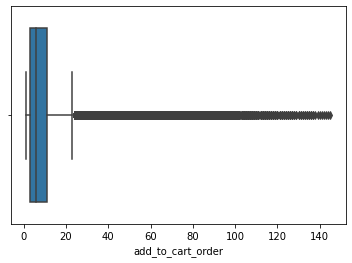

In [43]:
sns.boxplot(x=order_products__prior["add_to_cart_order"])

## Feature Engineering

In [14]:
prior_df = order_products__prior.merge(orders, on ='order_id', how='inner')
prior_df = prior_df.merge(products, on = 'product_id', how = 'left')
prior_df.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13


USER-LEVEL FEATURES

In [15]:
#Total orders by a user
user_total_orders = prior_df.groupby('user_id').order_number.max().rename('user_total_orders')

# Average basket size
basket_size = prior_df.groupby(['user_id', 'order_id']).size().groupby('user_id').mean().rename('user_avg_basket_size')

# User's overall reorder percentage
user_reorder_ratio = prior_df.groupby('user_id').reordered.mean().rename('user_reorder_ratio')

# Average time between orders
avg_time_between = prior_df.groupby('user_id')['days_since_prior_order'].mean().rename('user_avg_days_between_orders')

# Purchase frequency (Total items / Total orders)
# Need total items bought by user and total number of prior orders
total_items_bought_per_user = prior_df.groupby('user_id').size()
purchase_freq = (total_items_bought_per_user / user_total_orders).rename('user_purchase_frequency')

recency = prior_df.groupby('user_id')['days_since_prior_order'].agg(['min', 'max', 'mean', 'std'])
recency.columns = ['user_recency_min', 'user_recency_max', 'user_recency_mean', 'user_recency_std']

# User's average and std day-of-week of order
user_dow_features = prior_df.groupby('user_id')['order_dow'].agg(['mean', 'std']).rename(columns=lambda x: f'user_{x}_dow')

# User's average and std hour-of-day of order
user_hod_features = prior_df.groupby('user_id')['order_hour_of_day'].agg(['mean', 'std']).rename(columns=lambda x: f'user_{x}_hod')

# User's average and std days-since-prior-order (explicitly requested)
# Note: This is redundant with the 'recency' block above but included as per request.
user_days_since_prior_features = prior_df.groupby('user_id')['days_since_prior_order'].agg(['mean', 'std']).rename(columns=lambda x: f'user_{x}_days_since_prior_order')

# Total products user has bought (this is the total count of rows for the user in prior_df)
total_products_bought = prior_df.groupby('user_id').size().rename('user_total_products_bought')

# Total unique products user has bought
total_unique_products_bought = prior_df.groupby('user_id')['product_id'].nunique().rename('user_total_unique_products_bought')

# User's total reordered products
user_total_reordered_products = prior_df.groupby('user_id')['reordered'].sum().rename('user_total_reordered_products')

In [16]:
# Combine all user features
user_features_df = pd.concat([
    user_total_orders,
    basket_size,
    user_reorder_ratio,
    avg_time_between,
    purchase_freq,
    recency, # Contains mean/std of days_since_prior_order
    user_dow_features,
    user_hod_features,
    user_days_since_prior_features, # Explicitly adding mean/std of days_since_prior_order again
    total_products_bought,
    total_unique_products_bought,
    user_total_reordered_products
], axis=1)

In [17]:
user_features_df.head()

,user_total_orders,user_avg_basket_size,user_reorder_ratio,user_avg_days_between_orders,user_purchase_frequency,user_recency_min,user_recency_max,user_recency_mean,user_recency_std,user_mean_dow,user_std_dow,user_mean_hod,user_std_hod,user_mean_days_since_prior_order,user_std_days_since_prior_order,user_total_products_bought,user_total_unique_products_bought,user_total_reordered_products
user_id,,,,,,,,,,,,,,,,,,
1,10,5.900000,0.694915,18.542373,5.900000,0.0,30.0,18.542373,10.559065,2.644068,1.256194,10.542373,3.500355,18.542373,10.559065,59,18,41
2,14,13.928571,0.476923,14.902564,13.928571,0.0,30.0,14.902564,9.671712,2.005128,0.971222,10.441026,1.649854,14.902564,9.671712,195,102,93
3,12,7.333333,0.625000,10.181818,7.333333,0.0,21.0,10.181818,5.867396,1.011364,1.245630,16.352273,1.454599,10.181818,5.867396,88,33,55
4,5,3.600000,0.055556,11.944444,3.600000,0.0,21.0,11.944444,9.973330,4.722222,0.826442,13.111111,1.745208,11.944444,9.973330,18,17,1
5,4,9.250000,0.378378,10.189189,9.250000,0.0,19.0,10.189189,7.600577,1.621622,1.276961,15.729730,2.588958,10.189189,7.600577,37,23,14


D:\anacondaistall\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


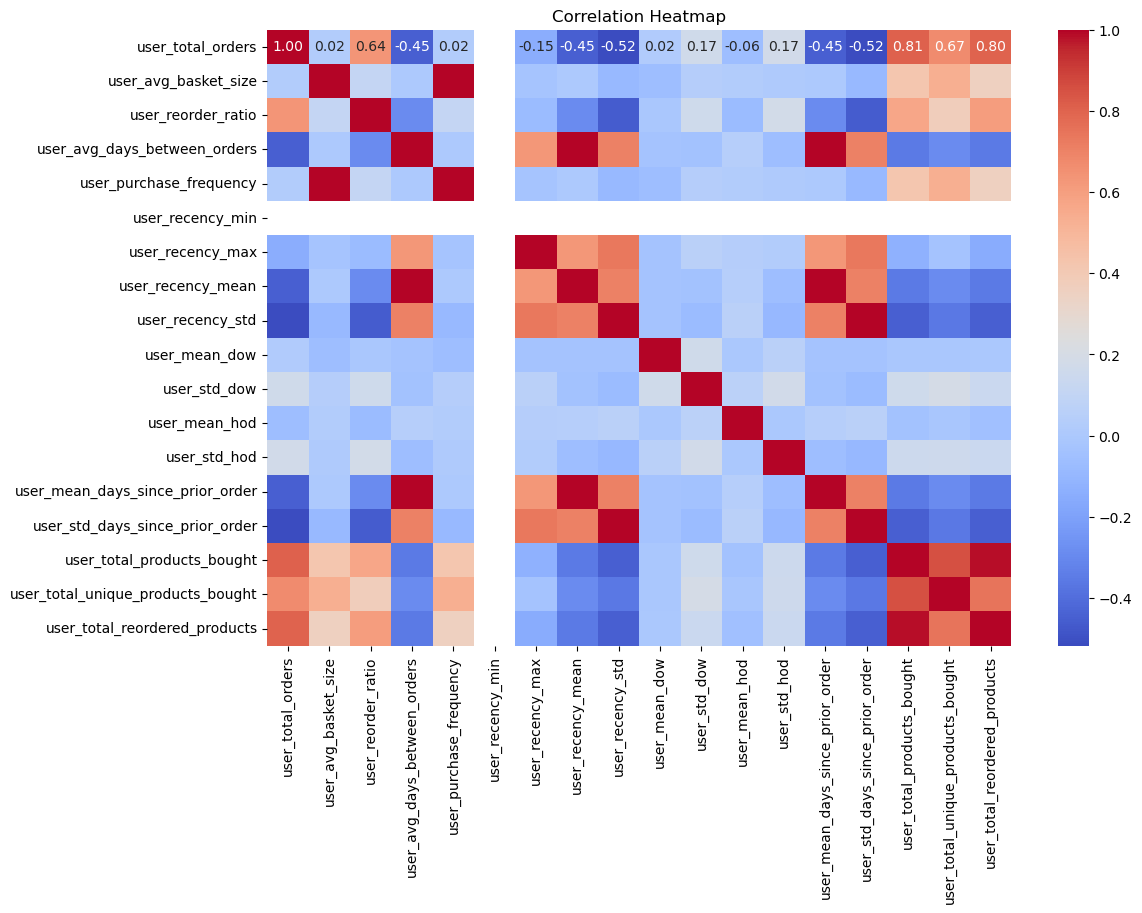

In [60]:
#Heatmap plot for correlation between numeric features
plt.figure(figsize=(12,8))
corr = user_features_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [38]:
user_features_df. isnull().sum()

user_total_orders                    0
user_avg_basket_size                 0
user_reorder_ratio                   0
user_avg_days_between_orders         0
user_purchase_frequency              0
user_recency_min                     0
user_recency_max                     0
user_recency_mean                    0
user_recency_std                     0
user_mean_dow                        0
user_std_dow                         0
user_mean_hod                        0
user_std_hod                         0
user_mean_days_since_prior_order     0
user_std_days_since_prior_order      0
user_total_products_bought           0
user_total_unique_products_bought    0
user_total_reordered_products        0
dtype: int64

PRODUCT-LEVEL FEATURES

In [18]:
# Total purchase count for each product
prod_total_count = prior_df.groupby('product_id').size().rename('prod_total_purchase_count')

# Global reorder rate for each product
prod_reorder_rate = prior_df.groupby('product_id').reordered.mean().rename('prod_global_reorder_rate')

# Popularity score (normalized purchase count)
popularity = (prod_total_count / prod_total_count.max()).rename('prod_popularity_score')

# Recency statistics for products (min, max, mean, std of days_since_prior_order for each product)
prod_recency = prior_df.groupby('product_id')['days_since_prior_order'].agg(['min', 'max', 'mean', 'std'])
prod_recency.columns = ['prod_recency_min', 'prod_recency_max', 'prod_recency_mean', 'prod_recency_std']

# Calculate total unique users of a product
prod_unique_users = prior_df.groupby('product_id')['user_id'].nunique().reset_index(name='prod_unique_users')

# Combine product features
product_features_df = pd.concat([
    prod_total_count,
    prod_reorder_rate,
    popularity,
    prod_recency,
    prod_unique_users
], axis=1)

In [19]:
product_features_df.head()

,prod_total_purchase_count,prod_global_reorder_rate,prod_popularity_score,prod_recency_min,prod_recency_max,prod_recency_mean,prod_recency_std,product_id,prod_unique_users
1,1852.0,0.613391,0.003919,0.0,30.0,9.880670,8.908765,2.0,78.0
2,90.0,0.133333,0.000190,0.0,30.0,10.133333,9.097722,3.0,74.0
3,277.0,0.732852,0.000586,0.0,30.0,9.916968,8.683461,4.0,182.0
4,329.0,0.446809,0.000696,0.0,30.0,12.945289,10.118357,5.0,6.0
5,15.0,0.600000,0.000032,0.0,30.0,11.600000,10.342699,6.0,5.0


In [18]:
product_features_df. isnull().sum()

prod_total_purchase_count     12
prod_global_reorder_rate      12
prod_popularity_score         12
prod_recency_min              12
prod_recency_max              12
prod_recency_mean             12
prod_recency_std             143
product_id                    12
prod_unique_users             12
dtype: int64

In [19]:
product_features_df = product_features_df.fillna(0)
product_features_df. isnull().sum()

prod_total_purchase_count    0
prod_global_reorder_rate     0
prod_popularity_score        0
prod_recency_min             0
prod_recency_max             0
prod_recency_mean            0
prod_recency_std             0
product_id                   0
prod_unique_users            0
dtype: int64

USER–PRODUCT INTERACTION FEATURES

In [20]:
# Interaction frequency (how many times a user bought a specific product)
user_prod_freq = prior_df.groupby(['user_id', 'product_id']).size().reset_index(name='user_prod_interaction_frequency')

# Recency of last purchase of a specific product by a user
last_purchase_order_num = prior_df.groupby(['user_id', 'product_id'])['order_number'].max().reset_index()
last_purchase_order_num.rename(columns={'order_number': 'user_prod_last_purchase_order'}, inplace=True)

# User-specific reorder rate for a product
user_prod_reorder_rate = prior_df.groupby(['user_id', 'product_id'])['reordered'].mean().reset_index()
user_prod_reorder_rate.rename(columns={'reordered': 'user_prod_reorder_rate'}, inplace=True)

# Average of adding to cart a Product for each user
user_prod_avg_add_to_cart = prior_df.groupby(['user_id', 'product_id'])['add_to_cart_order'].mean().reset_index()
user_prod_avg_add_to_cart.rename(columns={'add_to_cart_order': 'avg_add_to_cart_order'}, inplace=True)

# Average time between product orders for a user
user_prod_avg_days = prior_df.groupby(['user_id', 'product_id'])['days_since_prior_order'].mean().reset_index()
user_prod_avg_days.rename(columns={'days_since_prior_order': 'avg_days_since_prior_order'}, inplace=True)

# The last order number where the user purchased the product
user_prod_last_order = prior_df.groupby(['user_id', 'product_id'])['order_number'].max().reset_index()
user_prod_last_order.rename(columns={'order_number': 'last_order_number'}, inplace=True)

# Combine all features safely using merge
user_product_features_df = (
    user_prod_freq
    .merge(last_purchase_order_num, on=['user_id', 'product_id'], how='outer')
    .merge(user_prod_reorder_rate, on=['user_id', 'product_id'], how='outer')
    .merge(user_prod_avg_add_to_cart, on=['user_id', 'product_id'], how='outer')
    .merge(user_prod_avg_days, on=['user_id', 'product_id'], how='outer')
    .merge(user_prod_last_order, on=['user_id', 'product_id'], how='outer')
)

In [21]:
user_product_features_df.head()

,user_id,product_id,user_prod_interaction_frequency,user_prod_last_purchase_order,user_prod_reorder_rate,avg_add_to_cart_order,avg_days_since_prior_order,last_order_number
0,1,196,10,10,0.900000,1.400000,17.600000,10
1,1,10258,9,10,0.888889,3.333333,19.555556,10
2,1,10326,1,5,0.000000,5.000000,28.000000,5
3,1,12427,10,10,0.900000,3.300000,17.600000,10
4,1,13032,3,10,0.666667,6.333333,21.666667,10


In [44]:
user_product_features_df. isnull().sum()

user_id                            0
product_id                         0
user_prod_interaction_frequency    0
user_prod_last_purchase_order      0
user_prod_reorder_rate             0
avg_add_to_cart_order              0
avg_days_since_prior_order         0
last_order_number                  0
dtype: int64

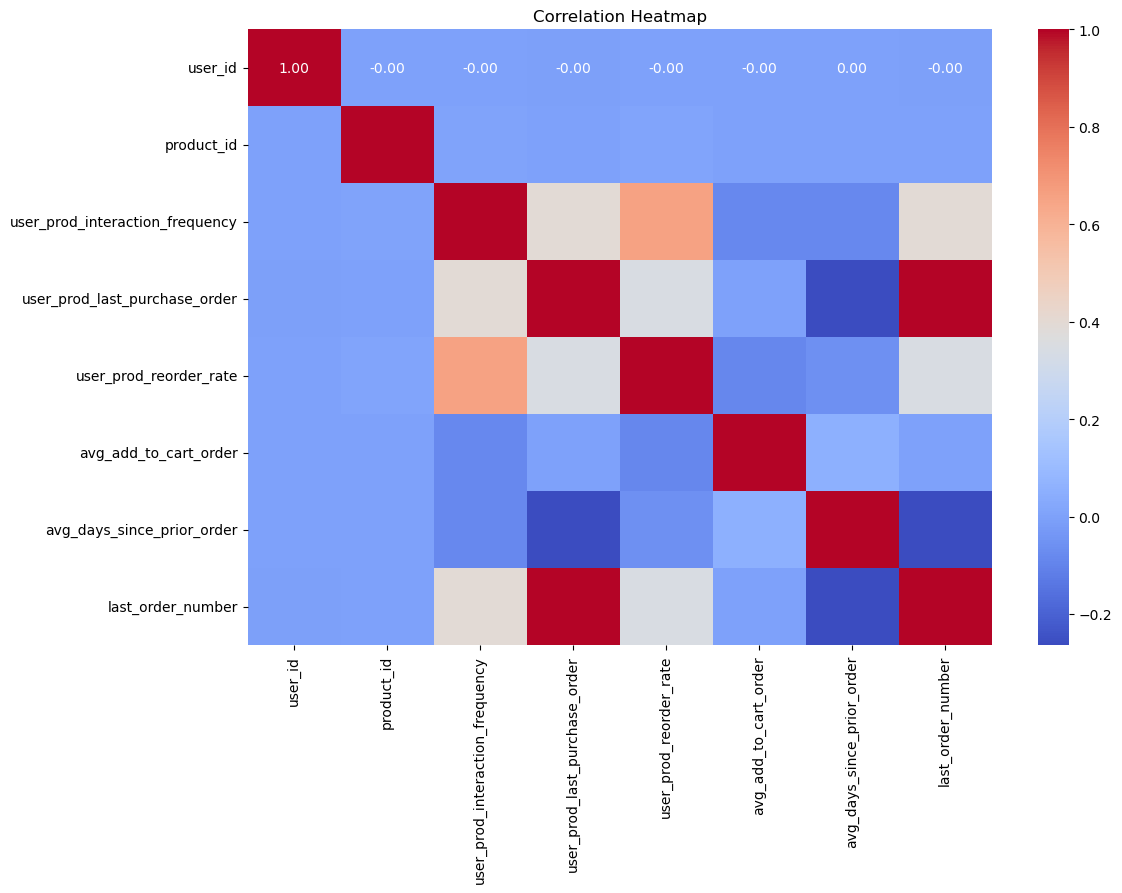

In [109]:
#Heatmap plot for correlation between numeric features
plt.figure(figsize=(12,8))
corr = user_product_features_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Dimension Reduction

### PCA

In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [26]:
data = user_features_df.values 

In [27]:
scaler = StandardScaler()
user_features_scaled = scaler.fit_transform(data)

In [73]:
pca_full = PCA().fit(user_features_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_85 = np.argmax(cumvar >= 0.85) + 1
print("Components for 85% variance:", n_components_85)

Components for 85% variance: 7


In [73]:
print("Variance explained by each component:")
for i, var in enumerate(pca_full.explained_variance_ratio_):
    print(f"components {i+1}: {var:.4f}")

print(f"\nCumulative variance explained:")
for i, cum_var in enumerate(cum_variance):
    print(f"components {i+1}: {cum_var:.4f}")

print(f"\nNumber of components required to retain 85% of the variance: {n_components_85}")

Variance explained by each component:
components 1: 0.3826
components 2: 0.1788
components 3: 0.1011
components 4: 0.0701
components 5: 0.0583
components 6: 0.0537
components 7: 0.0474
components 8: 0.0450
components 9: 0.0310
components 10: 0.0167
components 11: 0.0084
components 12: 0.0068
components 13: 0.0000
components 14: 0.0000
components 15: 0.0000
components 16: 0.0000
components 17: 0.0000
components 18: 0.0000

Cumulative variance explained:
components 1: 0.3826
components 2: 0.5614
components 3: 0.6625
components 4: 0.7326
components 5: 0.7909
components 6: 0.8446
components 7: 0.8920
components 8: 0.9370
components 9: 0.9680
components 10: 0.9848
components 11: 0.9932
components 12: 1.0000
components 13: 1.0000
components 14: 1.0000
components 15: 1.0000
components 16: 1.0000
components 17: 1.0000
components 18: 1.0000

Number of components required to retain 85% of the variance: 7


In [74]:
pca = PCA(n_components=n_components_85)
X_pca = pca.fit_transform(user_features_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Explained variance ratio:
[0.38259158 0.17883478 0.10108856 0.07007152 0.05831608 0.05372336
 0.04741719]


In [75]:
pca.components_[0]

array([ 2.98528382e-01,  1.04380991e-01,  2.33816537e-01, -3.18236932e-01,
        1.04380991e-01,  6.61744490e-24, -2.26943237e-01, -3.18236932e-01,
       -3.33548401e-01,  1.08213544e-02,  5.84100347e-02, -2.69321042e-02,
        6.36719135e-02, -3.18236932e-01, -3.33548401e-01,  3.03265331e-01,
        2.59530840e-01,  2.98243036e-01])

In [76]:
pca.components_[1]

array([ 0.13018969,  0.39080272,  0.13124161,  0.26163011,  0.39080272,
        0.        ,  0.29500164,  0.26163011,  0.16732872, -0.04359968,
        0.09340189,  0.02021749,  0.06584277,  0.26163011,  0.16732872,
        0.31375319,  0.34515111,  0.28117399])

### TSNE and Umap

In [30]:
from sklearn.manifold import TSNE

In [32]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,      # try 5–50
    learning_rate=200,
    #n_iter=1000,
    random_state=42
)

X_tsne = tsne.fit_transform(user_features_scaled)

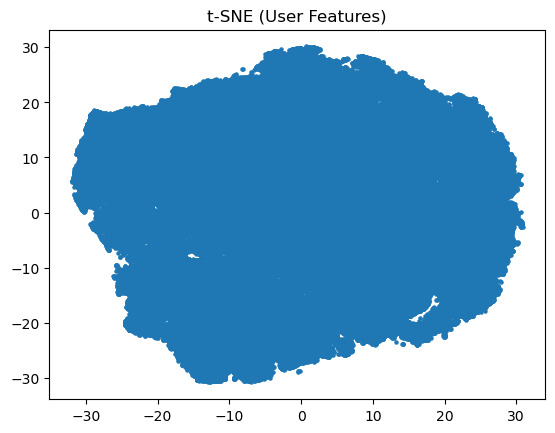

In [33]:
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=5)
plt.title("t-SNE (User Features)")
plt.show()

In [ ]:
from sklearn.manifold import TSNE

tsne1 = TSNE(
    n_components=2,
    perplexity=50,      # try 5–50
    learning_rate=200,
    #n_iter=1000,
    random_state=42
)

X_tsne1 = tsne1.fit_transform(user_features_scaled)
plt.scatter(X_tsne1[:, 0], X_tsne1[:, 1], s=5)
plt.title("t-SNE (User Features) with perplexity=50")
plt.show()

D:\anacondaistall\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


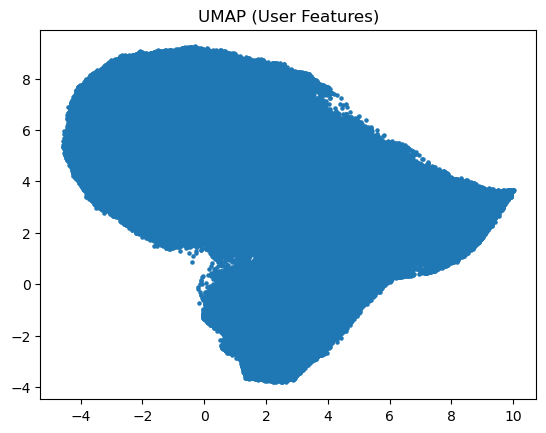

In [35]:
import umap

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,   # controls local vs global
    min_dist=0.1,
    random_state=42
)

X_umap = umap_model.fit_transform(user_features_scaled)

plt.scatter(X_umap[:, 0], X_umap[:, 1], s=5)
plt.title("UMAP (User Features)")
plt.show()

D:\anacondaistall\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


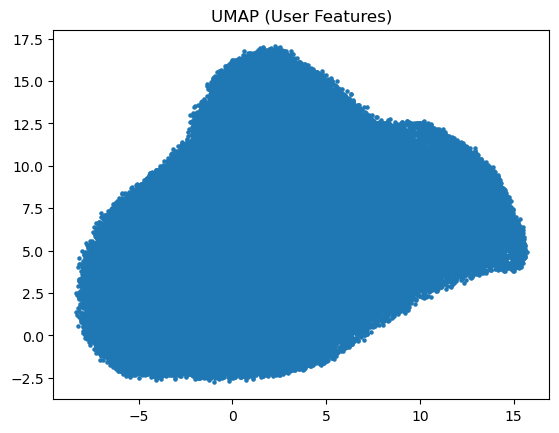

In [78]:
umap_model_30 = umap.UMAP(
    n_neighbors=150,
    min_dist=1,
    n_components=2,
    metric='euclidean',
    random_state=42
)

X_umap_30 = umap_model_30.fit_transform(user_features_scaled)

plt.scatter(X_umap_30[:, 0], X_umap_30[:, 1], s=5)
plt.title("UMAP (User Features)")
plt.show()

C:\Users\Samin  Mahboubfar\AppData\Local\Temp\ipykernel_6820\3069393425.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


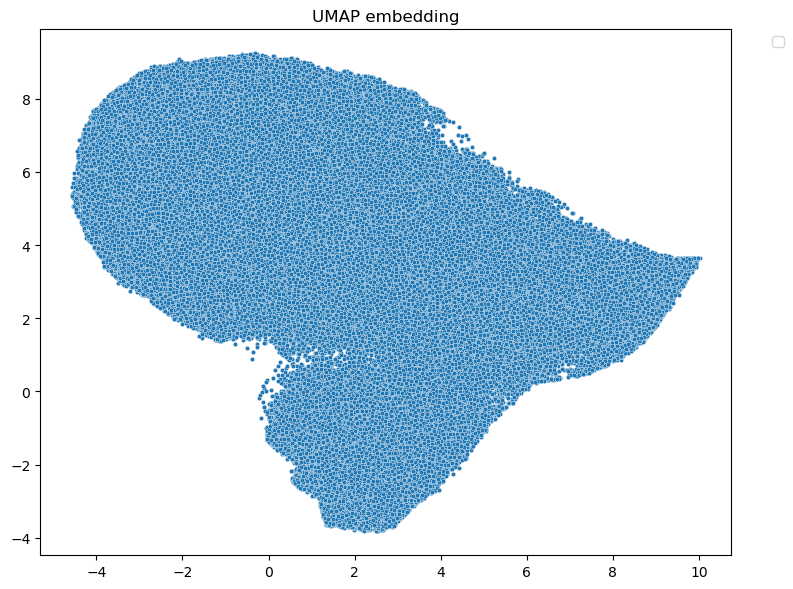

In [36]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    hue=y if 'y' in globals() else None,
    palette="Spectral",
    s=10
)
plt.title("UMAP embedding")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Modeling

In [22]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

import lightgbm as lgb
import xgboost as xgb

#### Data Prepration

In [23]:
train_orders = orders.merge(order_products__train, on = 'order_id', how = 'inner')
train_orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered
0,1187899,1,train,11,4,8,14.0,196,1,1
1,1187899,1,train,11,4,8,14.0,25133,2,1
2,1187899,1,train,11,4,8,14.0,38928,3,1
3,1187899,1,train,11,4,8,14.0,26405,4,1
4,1187899,1,train,11,4,8,14.0,39657,5,1


In [24]:
# Droping unimportant columns
train_orders.drop(['eval_set', 'add_to_cart_order', 'order_id'], axis = 1, inplace = True)

In [25]:
train_users = train_orders.user_id.unique()
train_users[:10]

array([ 1,  2,  5,  7,  8,  9, 10, 13, 14, 17], dtype=int64)

In [26]:
# Filtering to have only the rows related to the list users 
df = user_product_features_df[user_product_features_df.user_id.isin(train_users)]
df.head()

,user_id,product_id,user_prod_interaction_frequency,user_prod_last_purchase_order,user_prod_reorder_rate,avg_add_to_cart_order,avg_days_since_prior_order,last_order_number
0,1,196,10,10,0.900000,1.400000,17.600000,10
1,1,10258,9,10,0.888889,3.333333,19.555556,10
2,1,10326,1,5,0.000000,5.000000,28.000000,5
3,1,12427,10,10,0.900000,3.300000,17.600000,10
4,1,13032,3,10,0.666667,6.333333,21.666667,10


In [27]:
df = df.merge(train_orders, on = ['user_id', 'product_id'], how = 'outer')
df.head()

,user_id,product_id,user_prod_interaction_frequency,user_prod_last_purchase_order,user_prod_reorder_rate,avg_add_to_cart_order,avg_days_since_prior_order,last_order_number,order_number,order_dow,order_hour_of_day,days_since_prior_order,reordered
0,1,196,10.0,10.0,0.900000,1.400000,17.600000,10.0,11.0,4.0,8.0,14.0,1.0
1,1,10258,9.0,10.0,0.888889,3.333333,19.555556,10.0,11.0,4.0,8.0,14.0,1.0
2,1,10326,1.0,5.0,0.000000,5.000000,28.000000,5.0,NaN,NaN,NaN,NaN,NaN
3,1,12427,10.0,10.0,0.900000,3.300000,17.600000,10.0,NaN,NaN,NaN,NaN,NaN
4,1,13032,3.0,10.0,0.666667,6.333333,21.666667,10.0,11.0,4.0,8.0,14.0,1.0


In [29]:
df. isnull().sum()

user_id                                  0
product_id                               0
user_prod_interaction_frequency     555793
user_prod_last_purchase_order       555793
user_prod_reorder_rate              555793
avg_add_to_cart_order               555793
avg_days_since_prior_order          555793
last_order_number                   555793
order_number                       7645837
order_dow                          7645837
order_hour_of_day                  7645837
days_since_prior_order             7645837
reordered                          7645837
dtype: int64

In [30]:
df.order_number.fillna(df.groupby('user_id')['order_number'].transform('mean'), inplace = True)
df.order_dow.fillna(df.groupby('user_id')['order_dow'].transform('mean'), inplace = True)
df.order_hour_of_day.fillna(df.groupby('user_id')['order_hour_of_day'].transform('mean'), inplace = True)
df.days_since_prior_order.fillna(df.groupby('user_id')['days_since_prior_order'].\
                                                             transform('mean'), inplace = True)

In [31]:
df.reordered.value_counts()

reordered
1.0    828824
0.0    555793
Name: count, dtype: int64

In [95]:
df.reordered.isnull().sum()

0

In [32]:
df = df[df.reordered != 0]

In [33]:
df.reordered.fillna(0, inplace = True)

df.isnull().sum()

user_id                            0
product_id                         0
user_prod_interaction_frequency    0
user_prod_last_purchase_order      0
user_prod_reorder_rate             0
avg_add_to_cart_order              0
avg_days_since_prior_order         0
last_order_number                  0
order_number                       0
order_dow                          0
order_hour_of_day                  0
days_since_prior_order             0
reordered                          0
dtype: int64

In [34]:
df = df.merge(product_features_df, on = 'product_id', how = 'left')
df = df.merge(user_features_df, on = 'user_id', how = 'left')
df.head()

,user_id,product_id,user_prod_interaction_frequency,user_prod_last_purchase_order,user_prod_reorder_rate,avg_add_to_cart_order,avg_days_since_prior_order,last_order_number,order_number,order_dow,...,user_recency_std,user_mean_dow,user_std_dow,user_mean_hod,user_std_hod,user_mean_days_since_prior_order,user_std_days_since_prior_order,user_total_products_bought,user_total_unique_products_bought,user_total_reordered_products
0,1,196,10.0,10.0,0.900000,1.400000,17.600000,10.0,11.0,4.0,...,10.559065,2.644068,1.256194,10.542373,3.500355,18.542373,10.559065,59,18,41
1,1,10258,9.0,10.0,0.888889,3.333333,19.555556,10.0,11.0,4.0,...,10.559065,2.644068,1.256194,10.542373,3.500355,18.542373,10.559065,59,18,41
2,1,10326,1.0,5.0,0.000000,5.000000,28.000000,5.0,11.0,4.0,...,10.559065,2.644068,1.256194,10.542373,3.500355,18.542373,10.559065,59,18,41
3,1,12427,10.0,10.0,0.900000,3.300000,17.600000,10.0,11.0,4.0,...,10.559065,2.644068,1.256194,10.542373,3.500355,18.542373,10.559065,59,18,41
4,1,13032,3.0,10.0,0.666667,6.333333,21.666667,10.0,11.0,4.0,...,10.559065,2.644068,1.256194,10.542373,3.500355,18.542373,10.559065,59,18,41


In [38]:
df.fillna(0, inplace = True)

In [39]:
df.isnull().sum().sort_values(ascending = False)

user_id                              0
user_recency_std                     0
user_avg_basket_size                 0
user_reorder_ratio                   0
user_avg_days_between_orders         0
user_purchase_frequency              0
user_recency_min                     0
user_recency_max                     0
user_recency_mean                    0
user_mean_dow                        0
prod_unique_users                    0
user_std_dow                         0
user_mean_hod                        0
user_std_hod                         0
user_mean_days_since_prior_order     0
user_std_days_since_prior_order      0
user_total_products_bought           0
user_total_unique_products_bought    0
user_total_orders                    0
prod_recency_std                     0
product_id                           0
order_dow                            0
user_prod_interaction_frequency      0
user_prod_last_purchase_order        0
user_prod_reorder_rate               0
avg_add_to_cart_order    

In [40]:
def reduce_memory(df):
    
    """
    This function reduce the dataframe memory usage by converting it's type for easier handling.
    
    Parameters: Dataframe
    Return: Dataframe
    """
    
    start_mem_usg = df.memory_usage().sum() / 1024**2 
    print("Memory usage of properties dataframe is :",start_mem_usg," MB")
    
    for col in df.columns:
        if df[col].dtypes in ["int64", "int32", "int16"]:
            
            cmin = df[col].min()
            cmax = df[col].max()
            
            if cmin > np.iinfo(np.int8).min and cmax < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            
            elif cmin > np.iinfo(np.int16).min and cmax < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            
            elif cmin > np.iinfo(np.int32).min and cmax < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        
        if df[col].dtypes in ["float64", "float32"]:
            
            cmin = df[col].min()
            cmax = df[col].max()
            
            if cmin > np.finfo(np.float16).min and cmax < np.finfo(np.float16).max:
                df[col] = df[col].astype(np.float16)
            
            elif cmin > np.finfo(np.float32).min and cmax < np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
    
    print("")
    print("___MEMORY USAGE AFTER COMPLETION:___")
    mem_usg = df.memory_usage().sum() / 1024**2 
    print("Memory usage is: ",mem_usg," MB")
    print("This is ",100*mem_usg/start_mem_usg,"% of the initial size")
    
    return df

In [41]:
df = reduce_memory(df)

Memory usage of properties dataframe is : 2521.6048851013184  MB

___MEMORY USAGE AFTER COMPLETION:___
Memory usage is:  686.9757814407349  MB
This is  27.243593375777113 % of the initial size


In [42]:
df.head()

,user_id,product_id,user_prod_interaction_frequency,user_prod_last_purchase_order,user_prod_reorder_rate,avg_add_to_cart_order,avg_days_since_prior_order,last_order_number,order_number,order_dow,...,user_recency_std,user_mean_dow,user_std_dow,user_mean_hod,user_std_hod,user_mean_days_since_prior_order,user_std_days_since_prior_order,user_total_products_bought,user_total_unique_products_bought,user_total_reordered_products
0,1,196,10.0,10.0,0.899902,1.400391,17.593750,10.0,11.0,4.0,...,10.5625,2.644531,1.255859,10.539062,3.5,18.546875,10.5625,59,18,41
1,1,10258,9.0,10.0,0.888672,3.333984,19.562500,10.0,11.0,4.0,...,10.5625,2.644531,1.255859,10.539062,3.5,18.546875,10.5625,59,18,41
2,1,10326,1.0,5.0,0.000000,5.000000,28.000000,5.0,11.0,4.0,...,10.5625,2.644531,1.255859,10.539062,3.5,18.546875,10.5625,59,18,41
3,1,12427,10.0,10.0,0.899902,3.300781,17.593750,10.0,11.0,4.0,...,10.5625,2.644531,1.255859,10.539062,3.5,18.546875,10.5625,59,18,41
4,1,13032,3.0,10.0,0.666504,6.332031,21.671875,10.0,11.0,4.0,...,10.5625,2.644531,1.255859,10.539062,3.5,18.546875,10.5625,59,18,41


In [43]:
df.shape

(8474661, 39)

In [44]:
label = 'reordered'
x_cols = df.columns.drop('reordered')

In [45]:
X = df[x_cols]
y = df[label]

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, test_size = 0.25)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(6355995, 36) (6355995,)
(2118666, 36) (2118666,)


In [68]:
y_train.value_counts()

reordered
0.0    5734377
1.0     621618
Name: count, dtype: int64

In [69]:
np.ceil(y_train.value_counts()[0]/y_train.value_counts()[1])

10.0

In [70]:
y_test.value_counts()

reordered
0.0    1911460
1.0     207206
Name: count, dtype: int64

In [49]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve
import numpy as np
import matplotlib.pyplot as plt

gkf = GroupKFold(n_splits=3)

In [46]:
groups = df["user_id"]

gkf = GroupKFold(n_splits=3)

#### LIGHTGBM

In [47]:
import lightgbm as lgb

lgb_params = {
    "objective": "binary",
    "learning_rate": 0.05,
    "num_leaves": 64,
    "class_weight": "balanced"
}

all_true, all_pred = [], []

for train_idx, val_idx in gkf.split(X, y, groups):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(X_train, y_train)

    preds = model.predict_proba(X_val)[:, 1]

    all_true.extend(y_val)
    all_pred.extend(preds)

# threshold optimization
thresholds = np.linspace(0.1, 0.9, 50)
best_f1, best_thresh = 0, 0

for t in thresholds:
    pred_labels = (np.array(all_pred) > t).astype(int)
    f1 = f1_score(all_true, pred_labels)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best Threshold:", best_thresh)

y_pred_labels = (np.array(all_pred) > best_thresh).astype(int)

print("Precision:", precision_score(all_true, y_pred_labels))
print("Recall:", recall_score(all_true, y_pred_labels))
print("F1:", f1_score(all_true, y_pred_labels))
print("Confusion Matrix:\n", confusion_matrix(all_true, y_pred_labels))

[LightGBM] [Info] Number of positive: 552282, number of negative: 5097492
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.394761 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7025
[LightGBM] [Info] Number of data points in the train set: 5649774, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 552480, number of negative: 5097294
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.422110 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7021
[LightGBM] [Info] Number of data points in the train set: 5649774, number of used features: 37
[LightGBM]

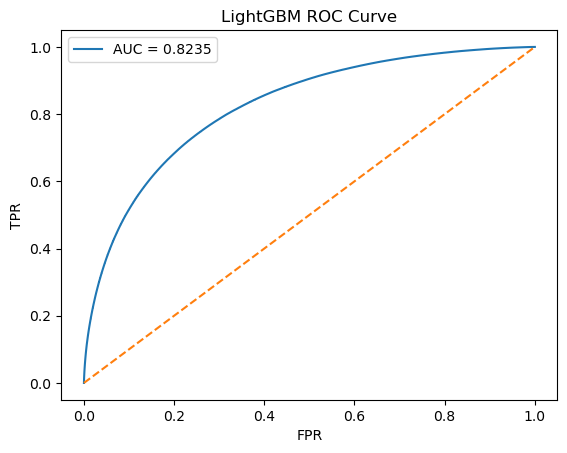

In [50]:
fpr, tpr, _ = roc_curve(all_true, all_pred)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(all_true, all_pred):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("LightGBM ROC Curve")
plt.legend()
plt.show()

#### XGBOOST

In [52]:
import xgboost as xgb

xgb_params = {
    "objective": "binary:logistic",
    "learning_rate": 0.05,
    "max_depth": 6,
    "n_estimators": 200,
    "scale_pos_weight": 10
}

all_true, all_pred = [], []

for train_idx, val_idx in gkf.split(X, y, groups):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = xgb.XGBClassifier(**xgb_params)
    model.fit(X_train, y_train)

    preds = model.predict_proba(X_val)[:, 1]

    all_true.extend(y_val)
    all_pred.extend(preds)

# threshold tuning
thresholds = np.linspace(0.1, 0.9, 50)
best_f1, best_thresh = 0, 0

for t in thresholds:
    pred_labels = (np.array(all_pred) > t).astype(int)
    f1 = f1_score(all_true, pred_labels)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best Threshold:", best_thresh)

y_pred_labels = (np.array(all_pred) > best_thresh).astype(int)

print("Precision:", precision_score(all_true, y_pred_labels))
print("Recall:", recall_score(all_true, y_pred_labels))
print("F1:", f1_score(all_true, y_pred_labels))
print("Confusion Matrix:\n", confusion_matrix(all_true, y_pred_labels))

Best Threshold: 0.7204081632653062
Precision: 0.3716293802310143
Recall: 0.49474194762699925
F1: 0.4244384306333806
Confusion Matrix:
 [[6952496  693341]
 [ 418770  410054]]


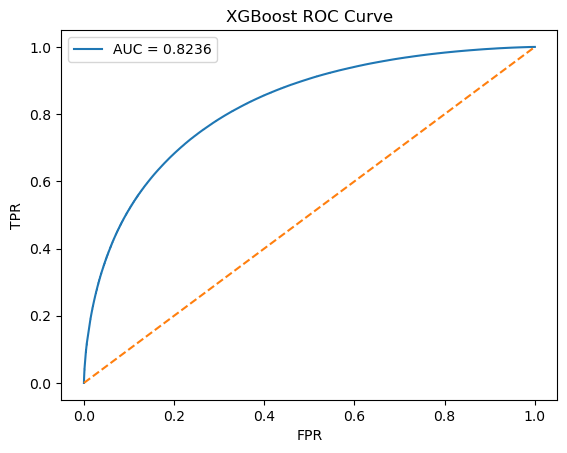

In [53]:
fpr, tpr, _ = roc_curve(all_true, all_pred)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(all_true, all_pred):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.show()

Lower threshold → ↑ Recall, ↓ Precision
Higher threshold → ↑ Precision, ↓ Recall

### Top K Recommendation System and Ranking Evaluation

In [54]:
df["pred"] = model.predict_proba(X)[:, 1]

K = 10

top_k = (
    df.sort_values(["user_id", "pred"], ascending=[True, False])
    .groupby("user_id")
    .head(K)
)

In [55]:
def precision_at_k(df, k=10):
    return df["reordered"].sum() / k

precision_scores = top_k.groupby("user_id").apply(precision_at_k)
print("Precision@K:", precision_scores.mean())

Precision@K: 0.29078569305459223


In [56]:
def recall_at_k(df, full_df):
    user = df.name
    total_relevant = full_df[(full_df.user_id == user)]["reordered"].sum()
    return df["reordered"].sum() / (total_relevant + 1e-9)

recall_scores = top_k.groupby("user_id").apply(lambda x: recall_at_k(x, df))
print("Recall@K:", recall_scores.mean())

Recall@K: 0.5289607298141722


In [59]:
hit_rate = top_k.groupby("user_id")["reordered"].max().mean()
print("Hit Rate@K:", hit_rate)

Hit Rate@K: nan


D:\anacondaistall\Lib\site-packages\pandas\core\nanops.py:1479: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
D:\anacondaistall\Lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
D:\anacondaistall\Lib\site-packages\pandas\core\nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan


In [58]:
from sklearn.metrics import ndcg_score

def ndcg_at_k(user_df):
    true = user_df["reordered"].values
    pred = user_df["pred"].values
    return ndcg_score([true], [pred])

ndcg = top_k.groupby("user_id").apply(ndcg_at_k).mean()
print("NDCG@K:", ndcg)

ValueError: Computing NDCG is only meaningful when there is more than 1 document. Got 1 instead.